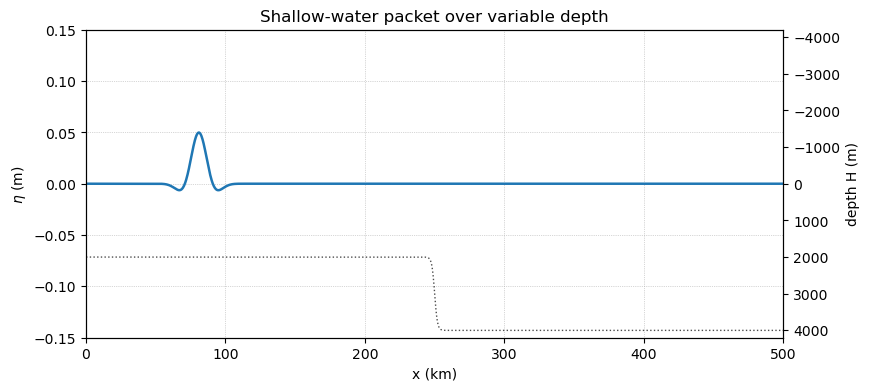


Depth ratio H1/H0 = 2.000, transition width L = 2.0 km
Transmission coefficient (energy): T ≈ 0.000
Reflection    coefficient (energy): R ≈ 1.000
Energy consistency: (T+R) ≈ 1.000  (≤ 1 due to sponge losses)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter

# ------------------------ user controls ------------------------
g   = 9.81
H0  = 2000.0
H1  = 4000.0
L   = 2e3
x0  = 250e3
Lx  = 500e3
nx  = 2000
tmax = 1500.0
cfl  = 0.9
sponge_len = 20e3
sponge_max = 1.0/2000.0
Aeta   = 0.05
x_eta0 = 80e3
sigma  = 8e3
k0     = 2*np.pi/40e3
every  = 3
# ---------------------------------------------------------------

# grid: C-grid (u at edges, eta at centers)
dx = Lx / nx
xc = (np.arange(nx) + 0.5) * dx
xe = np.arange(nx + 1) * dx

def H_profile(x):
    return 0.5*(H0 + H1) + 0.5*(H1 - H0)*np.tanh((x - x0)/L)

Hc = H_profile(xc)
He = H_profile(xe)
cmax = np.sqrt(g*np.max(Hc))
dt = cfl * dx / cmax
nt = int(np.ceil(tmax/dt))
dt = tmax/nt  # hit tmax exactly

# sponge
sigma_sponge = np.zeros_like(xc)
left_mask  = xc < sponge_len
right_mask = xc > (Lx - sponge_len)
sigma_sponge[left_mask]  = sponge_max*(1 - xc[left_mask]/sponge_len)
sigma_sponge[right_mask] = sponge_max*(1 - (Lx - xc[right_mask])/sponge_len)
sigma_u = np.interp(xe, xc, sigma_sponge)  # edges

# initial packet
eta = Aeta * np.exp(-0.5*((xc - x_eta0)/sigma)**2) * (np.cos(k0*(xc - x_eta0)) if k0 != 0 else 1.0)
c0  = np.sqrt(g*H0)
u   = np.zeros_like(xe)
init_mask = xc < x0 - 3*L
u_center_like = (c0/H0) * eta
u = np.interp(xe, xc, u_center_like) * np.where(xe < x0 - 3*L, 1.0, 0.0)

E_time = []; RL_time = []; times = []

# --------- discrete derivatives (C-grid) ----------
def d_dx_edge_to_center(qe):
    # center-length array (nx): (qe[i+1/2] - qe[i-1/2]) / dx
    return (qe[1:] - qe[:-1]) / dx

def d_dx_center_to_edge(qc):
    """
    Edge-length gradient (nx+1) matching u's shape.
    Use centered diffs on interior edges and copy end values to boundaries.
    """
    ge = np.zeros(qc.size + 1, dtype=qc.dtype)
    ge[1:-1] = (qc[1:] - qc[:-1]) / dx
    ge[0]    = ge[1]     # simple Neumann at boundaries
    ge[-1]   = ge[-2]
    return ge

# --------------- time stepper ----------------
def step(u, eta):
    # u^{n+1/2} = u^{n-1/2} - g dt d_x eta^n  (on edges)
    grad_eta = d_dx_center_to_edge(eta)      # shape (nx+1,) now
    u_new = u - g*dt*grad_eta
    u_new *= (1 - dt*sigma_u)                # sponge on u

    # eta^{n+1} = eta^n - dt d_x ( H u^{n+1/2} )  (on centers)
    Hu = He * u_new
    div_Hu = d_dx_edge_to_center(Hu)
    eta_new = eta - dt*div_Hu
    eta_new *= (1 - dt*sigma_sponge)         # sponge on eta

    return u_new, eta_new

# --------------- energy diagnostics ----------------
def energy_parts(u, eta):
    # simple linear wave-energy density (per unit width): 1/2 g eta^2 + 1/2 H u^2
    u_c = np.interp(xc, xe, u)
    Ec = 0.5*g*eta**2 + 0.5*Hc*(u_c**2)
    E_tot = np.trapezoid(Ec, xc)
    mid = int(np.floor(x0/dx))
    E_left  = np.trapezoid(Ec[:mid],  xc[:mid])  if mid > 0     else 0.0
    E_right = np.trapezoid(Ec[mid:],  xc[mid:])  if mid < nx    else 0.0
    return E_tot, E_left, E_right

E0, *_ = energy_parts(u, eta)

# --------------- figure & twin y-axis ----------------
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
line, = ax.plot(xc/1e3, eta, lw=1.8, label=r'$\eta$')
ax.set_xlabel('x (km)')
ax.set_ylabel(r'$\eta$ (m)')
ax.set_title('Shallow-water packet over variable depth')
ax.set_xlim(0, Lx/1e3)
ax.set_ylim(-Aeta*3, Aeta*3)
ax.grid(True, ls=':', lw=0.5)

# Right y-axis for depth
ax2 = ax.twinx()
depth_line, = ax2.plot(xc/1e3, Hc, ls=':', lw=1.0, color='k', alpha=0.7)
ax2.set_ylabel('depth H (m)')
ax2.set_ylim(np.max(Hc)*1.05, -np.max(Hc)*1.05)  # a little padding

def animate(frame):
    global u, eta
    for _ in range(every):
        u, eta = step(u, eta)

    line.set_ydata(eta)

    # auto y-limits for eta
    a = 1.05*np.max(np.abs(eta))
    yl = ax.get_ylim()
    if a > 0.9*max(abs(yl[0]), abs(yl[1])):
        ax.set_ylim(-a, a)

    # diagnostics (optional)
    Etot, El, Er = energy_parts(u, eta)
    E_time.append(Etot); RL_time.append((El, Er)); times.append((frame*every)*dt)

    # Only the eta line changes; for blitting return just that artist
    return (line,)

ani = FuncAnimation(fig, animate, frames=nt//every, interval=16, blit=True)
plt.show()

# ----------------- report T/R -----------------
Etot, El, Er = energy_parts(u, eta)
T = Er / E0
R = El / E0
print(f"\nDepth ratio H1/H0 = {H1/H0:.3f}, transition width L = {L/1e3:.1f} km")
print(f"Transmission coefficient (energy): T ≈ {T:.3f}")
print(f"Reflection    coefficient (energy): R ≈ {R:.3f}")
print(f"Energy consistency: (T+R) ≈ {T+R:.3f}  (≤ 1 due to sponge losses)")

writer = FFMpegWriter(fps=30, bitrate=1800)
ani.save(f"sw_packet_transmission_H0={H0}_H1={H1}.mp4", writer=writer)

# In-notebook display (works because ffmpeg is present)
from IPython.display import HTML
HTML(ani.to_html5_video())